# Generative Recurrent Neural Networks with PyTorch

## Overview

This notebook explores **generative recurrent neural networks (RNNs)** for character-level text generation using PyTorch. Unlike predictive sequence models that classify or label existing text, generative RNNs learn the probability distribution of sequential data and generate new text one character at a time.

The notebook introduces the complete generative modeling pipeline, including text preprocessing, character-level tokenization, recurrent neural network architecture, teacher forcing, autoregressive sequence generation, and sampling from learned probability distributions.

Much of content is an adaptation of the "Practical PyTorch" github
repository [1].

[1] https://github.com/spro/practical-pytorch/blob/master/char-rnn-generation/char-rnn-generation.ipynb

## Learning Objectives

By completing this notebook, you will learn how to:

- Build character-level recurrent neural networks
- Represent text as sequences of tokens
- Construct character vocabularies
- Encode and decode text sequences
- Train generative RNNs using teacher forcing
- Predict the next character in a sequence
- Generate text autoregressively
- Sample from learned probability distributions
- Implement generative language models in PyTorch

##  Character-Level Sequence Modeling

In recurrent neural networks the input sequence is broken down into tokens. We could choose whether to tokenize based on words, or based on characters. The representation of each token (GloVe or one-hot) is processed by the RNN one step at a time to update the hidden (or context) state.

In a predictive RNN, the value of the hidden states  is a representation of **all the text that was processed thus far**. Similarly, in a generative RNN, The value of the hidden state will be a representation of **all the text that still needs to be generated**. We will use this hidden state to produce the sequence, one token at a time.

Similar to the last tutorial we will break up the problem of generating text
to generating one token at a time.

We will do so with the help of two functions:

1. We need to be able to generate the *next* token, given the current
   hidden state. In practice, we get a probability distribution over
   the next token, and sample from that probability distribution.
2. We need to be able to update the hidden state somehow. To do so,
   we need two piece of information: the old hidden state, and the actual
   token that was generated in the previous step. The actual token generated
   will inform the subsequent tokens.

We will repeat both functions until a special "END OF SEQUENCE" token is
generated.

Note that there are several tricky things that we will have to figure out.
For example, how do we actually sample the actual token from the probability
distribution over tokens? What would we do during training, and how might
that be different from during testing/evaluation? We will answer those
questions as we implement the RNN.

For now, let's start with our training data.

## Data: Donald Trump's Tweets from 2018

The training set we use is a collection of Donald Trump's tweets from 2018.
We will only use tweets that are 140 characters or shorter, and tweets
that contains more than just a URL.
Since tweets often contain creative spelling and numbers, and upper vs lower
case characters are read very differently, we will use a character-level RNN.

To start, let us load the trump.csv file to Google Colab and provide access to the drive. The file can be obtained from Quercus.

In [ ]:
# Install gdown (run once)
!pip install -q gdown

import csv
import gdown

# Google Drive file ID
file_id = "1LinYW9nmPRKLbXSCCGSKJ9MvgcsijDly"

# Download the dataset
gdown.download(
    f"https://drive.google.com/uc?id={file_id}",
    output="trump.csv",
    quiet=False
)

# Load the tweets
with open("trump.csv", "r", encoding="utf-8") as f:
    tweets = [row[0] for row in csv.reader(f)]

print(f"Number of tweets: {len(tweets)}")

Downloading...
From: https://drive.google.com/uc?id=1LinYW9nmPRKLbXSCCGSKJ9MvgcsijDly
To: /content/trump.csv
100%|██████████| 3.39M/3.39M [00:00<00:00, 115MB/s]


Number of tweets: 22402


There are over 20000 tweets in this collection.
Let's look at a few of them, just to get a sense of the kind of text
we're dealing with:

In [ ]:
print(tweets[100])
print(tweets[1000])
print(tweets[10000])

God Bless the people of Venezuela!
It was my honor. THANK YOU! https://t.co/1LvqbRQ1bi
Nobody but Donald Trump will save Israel. You are wasting your time with these politicians and political clowns. Best! #SheldonAdelson


## Character-Level Text Generation
To introduce the training procedure, we first demonstrate how a recurrent neural network can learn to generate a single tweet. This simplified example illustrates the complete sequence generation pipeline before extending the approach to larger datasets.

Normally, when we build a new machine learn model, we want to make sure
that our model can overfit. To that end, we will first build a neural network
that can generate _one_ tweet really well. We can choose any tweet (or any other text)
we want.  Let's choose to build an RNN that generates `tweet[100]`.

In [ ]:
tweet = tweets[100]
print(tweet)
print(len(tweet))

God Bless the people of Venezuela!
34


First, we will need to encode this tweet using a one-hot encoding.
We'll build dictionary mappings
from the character to the index of that character (a unique integer identifier),
and from the index to the character. We'll use the same naming scheme that `torchtext`
uses (`stoi` and `itos`).

For simplicity, we'll work with a limited vocabulary containing
just the characters in `tweet[100]`, plus two special tokens:

- `<EOS>` represents "End of String", which we'll append to the end of our tweet.
  Since tweets are variable-length, this is a way for the RNN to signal
  that the entire sequence has been generated.
- `<BOS>` represents "Beginning of String", which we'll prepend to the beginning of
  our tweet. This is the first token that we will feed into the RNN.

The way we use these special tokens will become more clear as we build the model.

In [ ]:
vocab = list(set(tweet)) + ["<BOS>", "<EOS>"]
vocab_stoi = {s: i for i, s in enumerate(vocab)}
vocab_itos = {i: s for i, s in enumerate(vocab)}
vocab_size = len(vocab)

In [ ]:
print(vocab)
print(vocab_stoi)
print(vocab_itos)
print(vocab_size)

['h', 's', 'e', ' ', 'n', 'f', 'G', 'V', 'd', 'o', 'p', 't', 'z', 'u', 'B', 'a', 'l', '!', '<BOS>', '<EOS>']
{'h': 0, 's': 1, 'e': 2, ' ': 3, 'n': 4, 'f': 5, 'G': 6, 'V': 7, 'd': 8, 'o': 9, 'p': 10, 't': 11, 'z': 12, 'u': 13, 'B': 14, 'a': 15, 'l': 16, '!': 17, '<BOS>': 18, '<EOS>': 19}
{0: 'h', 1: 's', 2: 'e', 3: ' ', 4: 'n', 5: 'f', 6: 'G', 7: 'V', 8: 'd', 9: 'o', 10: 'p', 11: 't', 12: 'z', 13: 'u', 14: 'B', 15: 'a', 16: 'l', 17: '!', 18: '<BOS>', 19: '<EOS>'}
20


Now that we have our vocabulary, we can build the PyTorch model
for this problem.
The actual model is not as complex as you might think. We actually
already learned about all the components that we need. (Using and training
the model is the hard part)

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

In [ ]:
class TextGenerator(nn.Module):
    def __init__(self, vocab_size, hidden_size, n_layers=1):
        super(TextGenerator, self).__init__()

        # identiy matrix for generating one-hot vectors
        self.ident = torch.eye(vocab_size)

        # recurrent neural network
        self.rnn = nn.GRU(vocab_size, hidden_size, n_layers, batch_first=True)

        # a fully-connect layer that outputs a distribution over
        # the next token, given the RNN output
        self.decoder = nn.Linear(hidden_size, vocab_size)

    def forward(self, inp, hidden=None):
        inp = self.ident[inp]                  # generate one-hot vectors of input
        output, hidden = self.rnn(inp, hidden) # get the next output and hidden state
        output = self.decoder(output)          # predict distribution over next tokens
        return output, hidden

model = TextGenerator(vocab_size, 64)

## Training with Teacher Forcing

At a very high level, we want our RNN model to have a high probability
of generating the tweet. An RNN model generates text
one character at a time based on the hidden state value.
At each time step, we will check whether the mdoel generated the
correct character. That is, at each time step,
we are trying to select the correct next character out of all the
characters in our vocabulary. Recall that this problem is a multi-class
classification problem, and we can use Cross-Entropy loss to train our
network to become better at this type of problem.

In [ ]:
criterion = nn.CrossEntropyLoss()

However, we don't just have a single multi-class classification problem.
Instead, we have **one classification problem per time-step** (per token)!
So, how do we predict the first token in the sequence?
How do we predict the second token in the sequence?

To help you understand what happens durign RNN training, we'll start with a
inefficient training code that shows you what happens step-by-step. We'll
start with computing the loss for the first token generated, then the second token,
and so on.
Later on, we'll switch to a simpler and more performant version of the code.

So, let's start with the first classification problem: the problem of generating
the **first** token (`tweet[0]`).

To generate the first token, we'll feed the RNN network (with an initial, empty
hidden state) the "<BOS>" token. Then, the output

In [ ]:
bos_input = torch.Tensor([vocab_stoi["<BOS>"]])
print(bos_input.shape, type(bos_input))
bos_input = bos_input.long()
print(bos_input.shape, type(bos_input))
bos_input = bos_input.unsqueeze(0)
print(bos_input.shape, type(bos_input))
output, hidden = model(bos_input, hidden=None)
output # distribution over the first token

torch.Size([1]) <class 'torch.Tensor'>
torch.Size([1]) <class 'torch.Tensor'>
torch.Size([1, 1]) <class 'torch.Tensor'>


tensor([[[ 0.0775,  0.1251,  0.0367,  0.0696,  0.1557, -0.1493,  0.1428,
           0.1098,  0.0167, -0.0115, -0.0917, -0.0504,  0.0166,  0.0062,
           0.0243,  0.0537,  0.1255,  0.0434, -0.1604, -0.0726]]],
       grad_fn=<ViewBackward0>)

In [ ]:
bos_input

tensor([[18]])

We can compute the loss using `criterion`. Since the model is untrained,
the loss is expected to be high. (For now, we won't do anything
with this loss, and omit the backward pass.)

In [ ]:
target = torch.Tensor([vocab_stoi[tweet[0]]]).long().unsqueeze(0)
criterion(output.reshape(-1, vocab_size), # reshape to 2D tensor
          target.reshape(-1))             # reshape to 1D tensor

tensor(2.8803, grad_fn=<NllLossBackward0>)

In [ ]:
print(target)
print(output)
print(output.reshape(-1, vocab_size))
print(target.reshape(-1))

tensor([[6]])
tensor([[[ 0.0775,  0.1251,  0.0367,  0.0696,  0.1557, -0.1493,  0.1428,
           0.1098,  0.0167, -0.0115, -0.0917, -0.0504,  0.0166,  0.0062,
           0.0243,  0.0537,  0.1255,  0.0434, -0.1604, -0.0726]]],
       grad_fn=<ViewBackward0>)
tensor([[ 0.0775,  0.1251,  0.0367,  0.0696,  0.1557, -0.1493,  0.1428,  0.1098,
          0.0167, -0.0115, -0.0917, -0.0504,  0.0166,  0.0062,  0.0243,  0.0537,
          0.1255,  0.0434, -0.1604, -0.0726]], grad_fn=<ViewBackward0>)
tensor([6])


Now, we need to update the hidden state and generate a prediction
for the next token. To do so, we need to provide the current token to
the RNN. We already said that during test time, we'll need to sample
from the predicted probabilty over tokens that the neural network
just generated.

Right now, we can do something better: we can **use the ground-truth,
actual target token**. This technique is called **teacher-forcing**,
and generally speeds up training. The reason is that right now,
since our model does not perform well, the predicted probability
distribution is pretty far from the ground truth. So, it is very,
very difficult for the neural network to get back on track given bad
input data.

In [ ]:
# Use teacher-forcing: we pass in the ground truth `target`,
# rather than using the NN predicted distribution
output, hidden = model(target, hidden)
output # distribution over the second token

tensor([[[ 0.1104,  0.1643,  0.0111,  0.0547,  0.1513, -0.1343,  0.1341,
           0.0987,  0.0263, -0.0241, -0.0927, -0.0397,  0.0248, -0.0587,
          -0.0236,  0.0750,  0.1219,  0.0635, -0.1870, -0.0855]]],
       grad_fn=<ViewBackward0>)

Similar to the first step, we can compute the loss, quantifying the
difference between the predicted distribution and the actual next
token. This loss can be used to adjust the weights of the neural
network (which we are not doing yet).

In [ ]:
target = torch.Tensor([vocab_stoi[tweet[1]]]).long().unsqueeze(0)
criterion(output.reshape(-1, vocab_size), # reshape to 2D tensor
          target.reshape(-1))             # reshape to 1D tensor

tensor(3.0439, grad_fn=<NllLossBackward0>)

We can continue this process of:

- feeding the previous ground-truth token to the RNN,
- obtaining the prediction distribution over the next token, and
- computing the loss,

for as many steps as there are tokens in the ground-truth tweet.

In [ ]:
for i in range(2, len(tweet)):
    output, hidden = model(target, hidden)
    target = torch.Tensor([vocab_stoi[tweet[1]]]).long().unsqueeze(0)
    loss = criterion(output.reshape(-1, vocab_size), # reshape to 2D tensor
                     target.reshape(-1))             # reshape to 1D tensor
    print(i, output, loss)

2 tensor([[[ 0.1215,  0.1684,  0.0198,  0.0687,  0.1448, -0.1088,  0.1382,
           0.1033,  0.0307, -0.0294, -0.0773, -0.0302,  0.0252, -0.0539,
          -0.0111,  0.0697,  0.1576,  0.0775, -0.1880, -0.0796]]],
       grad_fn=<ViewBackward0>) tensor(3.0570, grad_fn=<NllLossBackward0>)
3 tensor([[[ 0.1224,  0.1704,  0.0227,  0.0807,  0.1398, -0.1018,  0.1358,
           0.1091,  0.0260, -0.0327, -0.0629, -0.0320,  0.0236, -0.0512,
          -0.0011,  0.0656,  0.1729,  0.0808, -0.1883, -0.0722]]],
       grad_fn=<ViewBackward0>) tensor(3.0634, grad_fn=<NllLossBackward0>)
4 tensor([[[ 0.1197,  0.1706,  0.0232,  0.0891,  0.1353, -0.1014,  0.1321,
           0.1148,  0.0198, -0.0348, -0.0519, -0.0359,  0.0217, -0.0501,
           0.0052,  0.0630,  0.1800,  0.0803, -0.1881, -0.0651]]],
       grad_fn=<ViewBackward0>) tensor(3.0665, grad_fn=<NllLossBackward0>)
5 tensor([[[ 0.1165,  0.1700,  0.0229,  0.0944,  0.1315, -0.1027,  0.1290,
           0.1196,  0.0146, -0.0361, -0.0443, -0.0393, 

Finally, with our final token, we should expect to output the "<EOS>"
token, so that our RNN learns when to stop generating characters.

In [ ]:
output, hidden = model(target, hidden)
target = torch.Tensor([vocab_stoi["<EOS>"]]).long().unsqueeze(0)
loss = criterion(output.reshape(-1, vocab_size), # reshape to 2D tensor
                 target.reshape(-1))             # reshape to 1D tensor
print(i, output, loss)

33 tensor([[[ 0.1081,  0.1655,  0.0227,  0.1021,  0.1214, -0.1060,  0.1239,
           0.1306,  0.0038, -0.0376, -0.0329, -0.0450,  0.0188, -0.0490,
           0.0129,  0.0596,  0.1891,  0.0745, -0.1881, -0.0467]]],
       grad_fn=<ViewBackward0>) tensor(3.0782, grad_fn=<NllLossBackward0>)


In practice, we don't really need a loop. Recall that in a predictive RNN,
the `nn.RNN` module can take an entire sequence as input. We can do the
same thing here:

In [ ]:
tweet_ch = ["<BOS>"] + list(tweet) + ["<EOS>"]
tweet_indices = [vocab_stoi[ch] for ch in tweet_ch]
tweet_tensor = torch.Tensor(tweet_indices).long().unsqueeze(0)

print(tweet_tensor.shape)

output, hidden = model(tweet_tensor[:,:-1]) # <EOS> is never an input token
target = tweet_tensor[:,1:]                 # <BOS> is never a target token
loss = criterion(output.reshape(-1, vocab_size), # reshape to 2D tensor
                 target.reshape(-1))             # reshape to 1D tensor

torch.Size([1, 36])


Here, the input to our neural network model is the *entire*
sequence of input tokens (everything from "<BOS>" to the
last character of the tweet). The neural network generates a prediction distribution
of the next token at each step. We can compare each of these  with the ground-truth
`target`.


Our training loop (for learning to generate the single `tweet`) will therefore
look something like this:

In [ ]:
print(tweet_tensor[:,:-1])
print(target)

tensor([[18,  6,  9,  8,  3, 14, 16,  2,  1,  1,  3, 11,  0,  2,  3, 10,  2,  9,
         10, 16,  2,  3,  9,  5,  3,  7,  2,  4,  2, 12, 13,  2, 16, 15, 17]])
tensor([[ 6,  9,  8,  3, 14, 16,  2,  1,  1,  3, 11,  0,  2,  3, 10,  2,  9, 10,
         16,  2,  3,  9,  5,  3,  7,  2,  4,  2, 12, 13,  2, 16, 15, 17, 19]])


In [ ]:
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()
for it in range(500):
    optimizer.zero_grad()
    output, _ = model(tweet_tensor[:,:-1])
    loss = criterion(output.reshape(-1, vocab_size),
                 target.reshape(-1))
    loss.backward()
    optimizer.step()

    if (it+1) % 100 == 0:
        print("[Iter %d] Loss %f" % (it+1, float(loss)))

/tmp/ipykernel_1076/1451665880.py:12: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:836.)
  print("[Iter %d] Loss %f" % (it+1, float(loss)))


[Iter 100] Loss 1.768285
[Iter 200] Loss 0.132759
[Iter 300] Loss 0.031132
[Iter 400] Loss 0.014288
[Iter 500] Loss 0.008488


The training loss is decreasing with training, which is what we expect.

## Generating a Token

At this point, we want to see whether our model is actually learning
something. So, we need to talk about how to
actually use the RNN model to generate text. If we can
generate text, we can make a qualitative asssessment of how well
our RNN is performing.

The main difference between training and test-time (generation time)
is that we don't have the ground-truth tokens to feed as inputs
to the RNN. Instead, we need to actually **sample** a token based
on the neural network's prediction distribution.

But how can we sample a token from a distribution?

On one extreme, we can always take
the token with the largest probability (argmax). This has been our
go-to technique in other classification tasks. However, this idea
will fail here. The reason is that in practice,
**we want to be able to generate a variety of different sequences from
the same model**. An RNN that can only generate a single new Trump Tweet
is fairly useless.

In short, we want some randomness. We can do so by using the logit
outputs from our model to construct a multinomial distribution over
the tokens, then and sample a random token from that multinomial distribution.

One natural multinomial distribution we can choose is the
distribution we get after applying the softmax on the outputs.
However, we will do one more thing: we will add a **temperature**
parameter to manipulate the softmax outputs. We can set a
**higher temperature** to make the probability of each token
**more even** (more random), or a **lower temperature** to assign
more probability to the tokens with a higher logit (output).
A **higher temperature** means that we will get a more diverse sample,
with potentially more mistakes. A **lower temperature** means that we
may see repetitions of the same high probability sequence.

In [ ]:
def sample_sequence(model, max_len=100, temperature=0.8):
    generated_sequence = ""

    inp = torch.Tensor([vocab_stoi["<BOS>"]]).long()
    hidden = None
    for p in range(max_len):
        output, hidden = model(inp.unsqueeze(0), hidden)
        # Sample from the network as a multinomial distribution
        output_dist = output.data.view(-1).div(temperature).exp()
        top_i = int(torch.multinomial(output_dist, 1)[0])
        # Add predicted character to string and use as next input
        predicted_char = vocab_itos[top_i]

        if predicted_char == "<EOS>":
            break
        generated_sequence += predicted_char
        inp = torch.Tensor([top_i]).long()
    return generated_sequence

print(sample_sequence(model, temperature=0.8))
print(sample_sequence(model, temperature=1.0))
print(sample_sequence(model, temperature=1.5))
print(sample_sequence(model, temperature=2.0))
print(sample_sequence(model, temperature=5.0))

God Bless the people of Venezuela!
God Bless the people of Venezuela!
God Blesssthe peopleoof Vfnezuela!
addBlless hhe aeople of aeszzue aa
hdhBzGlBdfdup apupedlofdBhh<BOS>aBala!


Since we only trained the model on a single sequence, we won't see
the effect of the temperature parameter yet.

For now, the output of the calls to the `sample_sequence` function
assures us that our training code looks reasonable, and we can
proceed to training on our full dataset!

## Training the Trump Tweet Generator

For the actual training, let's use `torchtext` so that we can use
the `BucketIterator` to make batches. Like in Lab 5, we'll create a
`torchtext.data.Field` to use `torchtext` to read the CSV file, and convert
characters into indices. The object has convient parameters to specify
the BOS and EOS tokens.

In [ ]:
import torch
print(torch.__version__)

2.11.0+cu128


In [ ]:
!pip install torchtext==0.1.1

In [ ]:
import torchtext

text_field = torchtext.data.Field(sequential=True,      # text sequence
                                  tokenize=lambda x: x, # because are building a character-RNN
                                  include_lengths=True, # to track the length of sequences, for batching
                                  batch_first=True,
                                  use_vocab=True,       # to turn each character into an integer index
                                  init_token="<BOS>",   # BOS token
                                  eos_token="<EOS>")    # EOS token


In [ ]:
import gdown
import torchtext

# Google Drive file ID
file_id = "1LinYW9nmPRKLbXSCCGSKJ9MvgcsijDly"

# Download the dataset
gdown.download(
    f"https://drive.google.com/uc?id={file_id}",
    output="trump.csv",
    quiet=False
)

# Define the fields
fields = [
    ('text', text_field),
    ('created_at', None),
    ('id_str', None)
]

# Load the dataset
trump_tweets = torchtext.data.TabularDataset(
    path="trump.csv",
    format="csv",
    fields=fields
)

print(f"Number of tweets: {len(trump_tweets)}")

Downloading...
From: https://drive.google.com/uc?id=1LinYW9nmPRKLbXSCCGSKJ9MvgcsijDly
To: /content/trump.csv
100%|██████████| 3.39M/3.39M [00:00<00:00, 113MB/s]


Number of tweets: 22402


In [ ]:
text_field.build_vocab(trump_tweets)
vocab_stoi = text_field.vocab.stoi # so we don't have to rewrite sample_sequence
vocab_itos = text_field.vocab.itos # so we don't have to rewrite sample_sequence
vocab_size = len(text_field.vocab.itos)
vocab_size

253

Let's just verify that the `BucketIterator` works as expected, but start with batch_size of 1.

In [ ]:
data_iter = torchtext.data.BucketIterator(
    trump_tweets,
    batch_size=1,
    sort_key=lambda x: len(x.text)
)

for batch in data_iter:
    print(batch)
    break

In [ ]:
for batch in data_iter:
    print(batch.text)
    break

(tensor([[ 2, 52, 39,  7,  6, 11,  8,  9,  7, 13, 35,  7, 20, 44, 24, 43, 10,  7,
         20,  5, 10,  4, 14,  6,  6, 18, 12, 32, 27, 27,  6, 22, 19,  8, 27,  9,
         51, 56, 19, 65, 16, 20, 75, 48, 70,  3]], device='cuda:0'), tensor([46], device='cuda:0'))


To account for batching, our actual training code will change, but just a little bit.
In fact, our training code from before will work with a batch size larger than one!

In [ ]:
def train(model, data, batch_size=1, num_epochs=1, lr=0.001, print_every=100):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()

    model.train()
    it = 0

    data_iter = torchtext.data.BucketIterator(
        data,
        batch_size=batch_size,
        sort_key=lambda x: len(x.text),
        device=-1,
        shuffle=True
    )

    for e in range(num_epochs):
        avg_loss = 0

        for batch in data_iter:
            tweet, lengths = batch.text

            target = tweet[:, 1:]
            inp = tweet[:, :-1]

            optimizer.zero_grad()

            output, _ = model(inp)

            loss = criterion(
                output.reshape(-1, vocab_size),
                target.reshape(-1)
            )

            loss.backward()
            optimizer.step()

            avg_loss += loss.item()
            it += 1

            if it % print_every == 0:
                print(f"[Iter {it}] Loss {avg_loss / print_every:.4f}")
                print("    " + sample_sequence(model, 140, 0.8))
                avg_loss = 0

In [ ]:
train(model, trump_tweets, batch_size=1, num_epochs=1, lr=0.004, print_every=100)
print(sample_sequence(model, temperature=0.8))
print(sample_sequence(model, temperature=0.8))
print(sample_sequence(model, temperature=1.0))
print(sample_sequence(model, temperature=1.0))
print(sample_sequence(model, temperature=1.5))
print(sample_sequence(model, temperature=1.5))
print(sample_sequence(model, temperature=2.0))
print(sample_sequence(model, temperature=2.0))
print(sample_sequence(model, temperature=5.0))
print(sample_sequence(model, temperature=5.0))

[Iter 100] Loss 3.7276
    IDAc .sAoyii.   o 0e.ron-.l me ylw.c te diV  rnioe  lrSnai NFl tra i0
[Iter 200] Loss 3.2917
    sAaG re  wOH re n Fd ro in ars. p(owo8me ton @y Ne IbaneroraltT fwos waomede bad orere
[Iter 300] Loss 3.1267
    SoEt Horecon tpll Gery Nn Pre  ralerYsorulDod ton wis tod 
[Iter 400] Loss 2.9493
    @@TMampt: Rger a @1U @unlg ank tuCale re Onimis rore nalertame p beleatle Se @UN 🇸e ping F7ke truDonlducold in tis thin  he itilis @STponily
[Iter 500] Loss 2.8107
    eall an Jot. ale ke bant leng wane ive g ous It fo te to he tot tept ol thet foc at is we the llat tha lo witinttitaz tow waw otht pe w Our 
[Iter 600] Loss 2.7160
    The foft but The teandero  nory #ar allor Iingel are tou thet srealan ong ant sime otirppo wareat.!
[Iter 700] Loss 2.6461
    ele sicars ane the gasips abellan'tongr cresth if aot tond &ertleas donan marint yhttp: @refurlikibrisallimpinkey tof er pofett the the Meav
[Iter 800] Loss 2.5575
    In UE .
[Iter 900] Loss 2.5367
    inivet wal

In [ ]:
train(model, trump_tweets, batch_size=32, num_epochs=1, lr=0.004, print_every=100)
print(sample_sequence(model, temperature=0.8))
print(sample_sequence(model, temperature=1.0))
print(sample_sequence(model, temperature=1.5))
print(sample_sequence(model, temperature=2.0))
print(sample_sequence(model, temperature=5.0))

## Generative RNN using GPU
Training a generative RNN can be a slow process. Here's a sample GPU implementation to speed up the training. The changes required to enable GPU are provided in the comments below.

In [ ]:
# Generative Recurrent Neural Network Implementation with GPU

def sample_sequence_cuda(model, max_len=100, temperature=0.8):
    generated_sequence = ""

    inp = torch.Tensor([vocab_stoi["<BOS>"]]).long().cuda()    # <----- GPU
    hidden = None
    for p in range(max_len):
        output, hidden = model(inp.unsqueeze(0), hidden)
        # Sample from the network as a multinomial distribution
        output_dist = output.data.view(-1).div(temperature).exp().cpu()
        top_i = int(torch.multinomial(output_dist, 1)[0])
        # Add predicted character to string and use as next input
        predicted_char = vocab_itos[top_i]

        if predicted_char == "<EOS>":
            break
        generated_sequence += predicted_char
        inp = torch.Tensor([top_i]).long().cuda()    # <----- GPU
    return generated_sequence


def train_cuda(model, data, batch_size=1, num_epochs=1, lr=0.001, print_every=100):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()
    it = 0
    data_iter = torchtext.data.BucketIterator(data,
                                              batch_size=batch_size,
                                              sort_key=lambda x: len(x.text),
                                              sort_within_batch=True)
    for e in range(num_epochs):
        # get training set
        avg_loss = 0
        for (tweet, lengths), label in data_iter:
            target = tweet[:, 1:].cuda()              # <------- GPU
            inp = tweet[:, :-1].cuda()                # <------- GPU
            # cleanup
            optimizer.zero_grad()
            # forward pass
            output, _ = model(inp)
            loss = criterion(output.reshape(-1, vocab_size), target.reshape(-1))
            # backward pass
            loss.backward()
            optimizer.step()

            avg_loss += loss
            it += 1 # increment iteration count
            if it % print_every == 0:
                print("[Iter %d] Loss %f" % (it+1, float(avg_loss/print_every)))
                print("    " + sample_sequence_cuda(model, 140, 0.8))
                avg_loss = 0

model = TextGenerator(vocab_size, 64)
model = model.cuda()
model.ident = model.ident.cuda()
train_cuda(model, trump_tweets, batch_size=32, num_epochs=1, lr=0.004, print_every=100)

In [ ]:
train_cuda(model, trump_tweets, batch_size=32, num_epochs=10, lr=0.004, print_every=500)

In [ ]:
train_cuda(model, trump_tweets, batch_size=32, num_epochs=10, lr=0.0001, print_every=500)

In [ ]:
train_cuda(model, trump_tweets, batch_size=32, num_epochs=10, lr=0.0001, print_every=500)

Let's generate some results using different levels of temperature.

In [ ]:
for i in range(5):
  print(sample_sequence_cuda(model, 140, 0.2))

In [ ]:
for i in range(5):
  print(sample_sequence_cuda(model, 140, 0.6))

In [ ]:
for i in range(5):
  print(sample_sequence_cuda(model, 140, 0.8))

@boolayda38: @realDonaldTrump @foxandfriends @realDonaldTrump Condrey13 months even on sime be interviewing for intervidance otter the bette
A now that do the @realDonaldTrump campicant to glable.
It is no she is a press us the seed it and our so great char great the siends.
@greila_nYarzah  @realDonaldTrump You nor dearmery in numberument Speitl All Opan and be a bad time of no campicales (stading and Governg ME
@joxBir61: @realDonaldTrump http://t.co/SIp6lJyVs"


In [ ]:
for i in range(5):
  print(sample_sequence_cuda(model, 140, 1))

@Trold14: @realDonaldTrump has was as awa to time ase'm going... in puppais! #TOUTBS PUNTLO NATIOR!
Need been Both @realDonaldTrump incration? President Ociamo frand.
Hillary Clinton's Donald This's the interentirs about about. Thank you!
Law! Thanks: Trump: Flowly up “Pass thanks.
IT Presidention firee 8! #HietAme  hlinane! https://t.co/EP0WHcE1Do


In [ ]:
for i in range(5):
  print(sample_sequence_cuda(model, 140, 1.5))

Frawing nypifn NERQ betoons 3/27:!bone!! https://t.co/rOomgd15
Histon pollory-andwing Trump.
@SpahL_AlISGLAAG: @flhIrnezoOsS THU POILT HAl542. @rearTurpht But stoe repricauleth hagieled https://t.co/BxCCa6R65l
S Amgrinnelweria scot'vue he's great two wept Jeb! Your- Sen.#CarenitCBue.TPretect!
@TSdekok7726 Existamy folcttk:///Royizaly!


# PART 2 - Transfer Learning for Text

https://github.com/karthikayan4u/Simplified-ULMFIT-for-Twitter-Airlines-Sentiment-Classification/blob/master/SimplifiedULMFIT.ipynb

In [ ]:
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
from fastai.text import *
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix

In [ ]:
import gdown
import pandas as pd

# Google Drive file ID
file_id = "1xN4IO6-NieQ5hBYnZiCEDSmLkbePIXKE"

# Download the file
gdown.download(
    f"https://drive.google.com/uc?id={file_id}",
    output="Tweets.csv",
    quiet=False
)

# Load the CSV
df = pd.read_csv("Tweets.csv")

# Check the data
print(df.head())
print(df.shape)

In [ ]:
df.head()

,tweet_id,airline_sentiment,airline_sentiment_confidence,negativereason,negativereason_confidence,airline,airline_sentiment_gold,name,negativereason_gold,retweet_count,text,tweet_coord,tweet_created,tweet_location,user_timezone
0,570306133677760513,neutral,1.0000,NaN,NaN,Virgin America,NaN,cairdin,NaN,0,@VirginAmerica What @dhepburn said.,NaN,2015-02-24 11:35:52 -0800,NaN,Eastern Time (US & Canada)
1,570301130888122368,positive,0.3486,NaN,0.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica plus you've added commercials t...,NaN,2015-02-24 11:15:59 -0800,NaN,Pacific Time (US & Canada)
2,570301083672813571,neutral,0.6837,NaN,NaN,Virgin America,NaN,yvonnalynn,NaN,0,@VirginAmerica I didn't today... Must mean I n...,NaN,2015-02-24 11:15:48 -0800,Lets Play,Central Time (US & Canada)
3,570301031407624196,negative,1.0000,Bad Flight,0.7033,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica it's really aggressive to blast...,NaN,2015-02-24 11:15:36 -0800,NaN,Pacific Time (US & Canada)
4,570300817074462722,negative,1.0000,Can't Tell,1.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica and it's a really big bad thing...,NaN,2015-02-24 11:14:45 -0800,NaN,Pacific Time (US & Canada)


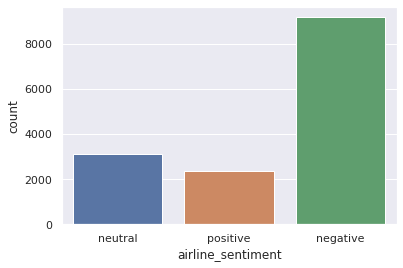

In [ ]:
# Distribution of the respective 3 sentiments.
sns.set(style="darkgrid")
ax = sns.countplot(x="airline_sentiment", data=df)

[Text(0, 0, 'Bad Flight'),
 Text(0, 0, "Can't Tell"),
 Text(0, 0, 'Late Flight'),
 Text(0, 0, 'Customer Service Issue'),
 Text(0, 0, 'Flight Booking Problems'),
 Text(0, 0, 'Lost Luggage'),
 Text(0, 0, 'Flight Attendant Complaints'),
 Text(0, 0, 'Cancelled Flight'),
 Text(0, 0, 'Damaged Luggage'),
 Text(0, 0, 'longlines')]

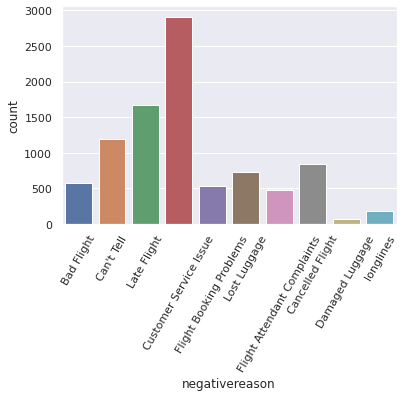

In [ ]:
# Distribution of the negative sentiment.
ax = sns.countplot(x='negativereason',data=df)
ax.set_xticklabels(ax.get_xticklabels(), rotation=60)

In [ ]:
import re

def removeUnicode(text):
  """ Removes unicode strings like "\u002c" and "x96" """
  text = re.sub(r'(\\u[0-9A-Fa-f]+)',r'', text)
  text = re.sub(r'[^\x00-\x7f]',r'',text)
  return text

def replaceURL(text):
  """Replaces url address with "url" """
  text = re.sub('((www\.[^\s]+)|(https?://[^\s]+))','url',text)
  text = re.sub(r'#([^\s]+)', r'\1', text)
  return text

def replaceAtUser(text):
  """ Replaces "@user" with "atUser" """
  # text = re.sub('@[^\s]+','atUser',text)
  text = re.sub('@[^\s]+','',text)
  return text

def removeHashtagInFrontOfWord(text):
  """ Removes hastag in front of a word """
  text = re.sub(r'#([^\s]+)', r'\1', text)
  return text

def removeNumbers(text):
  """ Removes integers """
  text = ''.join([i for i in text if not i.isdigit()])
  return text

def removeEmoticons(text):
  """ Removes emoticons from text """
  text = re.sub(':\)|;\)|:-\)|\(-:|:-D|=D|:P|xD|X-p|\^\^|:-*|\^\.\^|\^\-\^|\^\_\^|\,-\)|\)-:|:\'\(|:\(|:-\(|:\S|T\.T|\.\_\.|:<|:-\S|:-<|\*\-\*|:O|=O|=\-O|O\.o|XO|O\_O|:-\@|=/|:/|X\-\(|>\.<|>=\(|D:', '', text)
  return text


""" Replaces contractions from a string to their equivalents """
contraction_patterns = [ (r'won\'t', 'will not'), (r'can\'t', 'cannot'), (r'i\'m', 'i am'), (r'ain\'t', 'is not'), (r'(\w+)\'ll', '\g<1> will'), (r'(\w+)n\'t', '\g<1> not'),
                         (r'(\w+)\'ve', '\g<1> have'), (r'(\w+)\'s', '\g<1> is'), (r'(\w+)\'re', '\g<1> are'), (r'(\w+)\'d', '\g<1> would'), (r'&', 'and'), (r'dammit', 'damn it'), (r'dont', 'do not'), (r'wont', 'will not') ]
def replaceContraction(text):
  patterns = [(re.compile(regex), repl) for (regex, repl) in contraction_patterns]
  for (pattern, repl) in patterns:
      (text, count) = re.subn(pattern, repl, text)
  return text

In [ ]:
def preprocessTwitterData(df):
  """Function to apply text preprocessing functions to a dataframe"""

  # remove unicode
  df['text'] = df['text'].apply(removeUnicode)

  # replace url
  df['text'] = df['text'].apply(replaceURL)

  # replace '@' signs
  df['text'] = df['text'].apply(replaceAtUser)


  # replace hastags
  df['text'] = df['text'].apply(removeHashtagInFrontOfWord)

  # remove numbers in the tweets
  df['text'] = df['text'].apply(removeNumbers)

  # remove the emoticons
  df['text'] = df['text'].apply(removeEmoticons)

  # replace contractions
  df['text'] = df['text'].apply(replaceContraction)

# Call the function and preprocess the data
preprocessTwitterData(df)

# Since we don't need the rest of the columns in the data, subindex the relevant columns and make this the new dataframe
df = df[['text','airline_sentiment']]

# Split the dataset into a train and test set.
# Using a validation set is built into the fastai API, so we don't need to do this split ourselves

# use an 80-20 split for the train and test sets
df_train, df_test = train_test_split(df,test_size=0.1,random_state=20)

# Convert the cleaned training and testing data into their own CSV files which we can import later to perform modeling on them

df_train.to_csv('twitter_data_cleaned_train.csv')
df_test.to_csv('twitter_data_cleaned_test.csv')

In [ ]:
# Create a 'TextLMDataBunch' from a csv file.
# We specify 'valid=0.1' to signify that when we want to actually put this into our language model, we'll be setting off 10% of it for a validation set
data_batch = TextLMDataBunch.from_csv(path='',csv_name='twitter_data_cleaned_train.csv',valid_pct=0.1)

# run this to see how the batch looks like
data_batch.show_batch()

/usr/local/lib/python3.7/dist-packages/fastai/core.py:302: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray
  return np.array(a, dtype=dtype, **kwargs)


idx,text
0,fly with xxup aa xxunk within the usa . xxmaj thanks for confirming xxbos i hope i can take my selfie stick on the plane today ! xxunk xxbos what are the odds you can get me on a flight with delta so i can actually get to xxmaj orlando today ? ? xxunk xxmaj flight xxbos \n xxmaj not one to complain much but really hour minutes and
1,for a xxmaj flight xxmaj attendant who is nt up on current policy to argue with a traveler . xxbos is z and d code airfare refundable ? xxbos my goodness your people field are amazing under pressure from xxmaj texas xxunk in crisis xxmaj please fly me to xxup ny xxbos [ xxmaj part of ] she tried calling cust serv and the system hung up and her .
2,"thank you . xxbos , nd time this occurred in weeks . i 'm not patient . i have no choice . xxmaj xxunk issue xxbos xxmaj how to find out if my parents luggage really went to xxup fll on a xxmaj cancelled xxmaj flighted xxup sw flight ? xxmaj called xxunk , long long waits ... xxbos xxmaj ever consider coming to xxmaj memphis ? xxmaj need some"
3,"for no reason . xxmaj almost hrs xxmaj late xxmaj flight . xxunk xxup xxunk xxbos xxmaj buying xxmaj early xxmaj bird was pointless . xxmaj you moved me to a diff flight b / c first one was delayed , so i lost my boarding position . xxbos this airline is a joke my friends been trapped in houston since am sat and have no flight in sight xxunk"
4,"like talking to a xxunk xxunk who refuses to talk to you . useless xxunk xxup fail xxbos i know one thing would xxup never treat their customers like this xxrep 4 ! xxbos xxup dm the locator code , thanks . xxbos does not know the meaning of customer service . xxmaj nightmare . xxmaj paid for direct flight . xxmaj bumped to xxmaj dallas . xxmaj flight xxmaj"


In [ ]:
# pass in our 'data_lm' objet to specify our Twitter data
# pass in AWD_LSTM to specify that we're using this particular language model
tweet_model = language_model_learner(data_batch, AWD_LSTM, drop_mult=0.3)

In [ ]:
tweet_model.model

SequentialRNN(
  (0): AWD_LSTM(
    (encoder): Embedding(5184, 400, padding_idx=1)
    (encoder_dp): EmbeddingDropout(
      (emb): Embedding(5184, 400, padding_idx=1)
    )
    (rnns): ModuleList(
      (0): WeightDropout(
        (module): LSTM(400, 1152, batch_first=True)
      )
      (1): WeightDropout(
        (module): LSTM(1152, 1152, batch_first=True)
      )
      (2): WeightDropout(
        (module): LSTM(1152, 400, batch_first=True)
      )
    )
    (input_dp): RNNDropout()
    (hidden_dps): ModuleList(
      (0): RNNDropout()
      (1): RNNDropout()
      (2): RNNDropout()
    )
  )
  (1): LinearDecoder(
    (decoder): Linear(in_features=400, out_features=5184, bias=True)
    (output_dp): RNNDropout()
  )
)

In [ ]:
# fastai learning-rate finding
# implemented using fastai callbacks
#learning_rate_finder is used to find the optimal learning rate .
tweet_model.lr_find()

LR Finder is complete, type {learner_name}.recorder.plot() to see the graph.


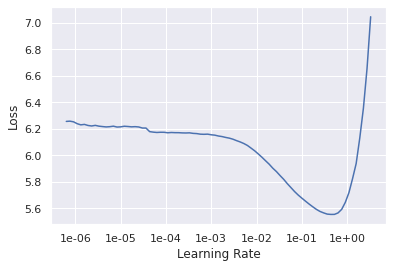

In [ ]:
# plot the graph we were talking about earlier
tweet_model.recorder.plot()

In [ ]:
# We set cycle_len to 1 because we only train with one epoch 'moms' refers to a tuple with the form (max_momentum,min_momentum)
tweet_model.fit_one_cycle(cyc_len=1,max_lr=1e-1,moms=(0.85,0.75))

epoch,train_loss,valid_loss,accuracy,time
0,4.660678,4.224733,0.238520,08:02


In [ ]:
# unfreeze the LSTM layers of the model
tweet_model.unfreeze()

In [ ]:
#Now let's train the model
tweet_model.fit_one_cycle(cyc_len=5, max_lr=slice(1e-1/(2.6**4),1e-1), moms=(0.85, 0.75))

In [ ]:
# save the encoder
tweet_model.save_encoder('encoder')

In [ ]:
# create 'TextClasDataBunch'
# pass in vocab to ensure the vocab is the
# same one that was modified in the fine-tuned LM
data_class = TextClasDataBunch.from_csv(path='',csv_name='twitter_data_cleaned_train.csv',
                              vocab=data_batch.train_ds.vocab,bs=32,text_cols='text',label_cols='airline_sentiment')

# show what our batch looks like
data_class.show_batch()

In [ ]:
# create new learner object with the 'text_classifier_learner' object.
# The concept behind this learner is the same as the 'language_model_learner'.
# It can similarly take in callbacks that allow us to train with special optimization methods. We use a slightly bigger dropout this time
tweet_model = text_classifier_learner(data_class, AWD_LSTM, drop_mult=0.5)

# load the fine-tuned encoder onto the learner
tweet_model.load_encoder('encoder')

# look at the model
tweet_model.model

In [ ]:
# find the optimal learning rate, just like we did before
tweet_model.lr_find()

# plot it
tweet_model.recorder.plot()

In [ ]:
# like we did before, we choose a learning rate before
# the minimum of the graph and use the 1cycle policy
tweet_model.fit_one_cycle(5,1e-1,moms=(0.8,0.7))

epoch,train_loss,valid_loss,accuracy,time
0,0.839697,0.776165,0.685888,05:35
1,0.888243,0.754227,0.681335,05:45
2,0.820804,0.699295,0.704097,05:28
3,0.740860,0.626765,0.743551,05:16
4,0.753172,0.638004,0.718513,05:23


/usr/local/lib/python3.7/dist-packages/numpy/core/_asarray.py:83: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray
  return array(a, dtype, copy=False, order=order)
<string>:6: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray
/usr/local/lib/python3.7/dist-packages/numpy/core/_asarray.py:83: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray
  return ar

In [ ]:
# unfreeze next layer
tweet_model.freeze_to(-2)

# train with next layer unfrozen, apply discriminative fine-tuning
tweet_model.fit_one_cycle(5,slice(1e-2/(2.6**4),1e-2))

epoch,train_loss,valid_loss,accuracy,time
0,0.693579,0.622566,0.758346,06:22
1,0.685722,0.574486,0.757587,06:15
2,0.619530,0.554008,0.776935,06:46
3,0.557712,0.615820,0.791730,07:19
4,0.557136,0.544140,0.795144,07:32


/usr/local/lib/python3.7/dist-packages/numpy/core/_asarray.py:83: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray
  return array(a, dtype, copy=False, order=order)
<string>:6: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray
/usr/local/lib/python3.7/dist-packages/numpy/core/_asarray.py:83: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray
  return ar

In [ ]:
# repeat the process
tweet_model.freeze_to(-3)
tweet_model.fit_one_cycle(5,slice(1e-2/(2.6**4),1e-2))

epoch,train_loss,valid_loss,accuracy,time
0,0.582463,0.546531,0.802731,12:15
1,0.570168,0.482219,0.809939,11:19
2,0.451357,0.492796,0.798938,10:27
3,0.363688,0.511320,0.806146,10:16
4,0.292236,0.543587,0.811836,10:44


/usr/local/lib/python3.7/dist-packages/numpy/core/_asarray.py:83: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray
  return array(a, dtype, copy=False, order=order)
<string>:6: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray
/usr/local/lib/python3.7/dist-packages/numpy/core/_asarray.py:83: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray
  return ar

In [ ]:
# now unfreeze everything
tweet_model.unfreeze()
tweet_model.fit_one_cycle(5,slice(1e-2/(2.6**4),1e-2))

epoch,train_loss,valid_loss,accuracy,time
0,0.307602,0.539995,0.801593,16:25
1,0.384783,0.812796,0.792109,17:14
2,0.270059,0.594188,0.804249,16:10
3,0.165827,0.615640,0.806904,16:51
4,0.131056,0.646923,0.814492,16:21


/usr/local/lib/python3.7/dist-packages/numpy/core/_asarray.py:83: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray
  return array(a, dtype, copy=False, order=order)
<string>:6: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray
/usr/local/lib/python3.7/dist-packages/numpy/core/_asarray.py:83: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray
  return ar

# Prediction Phase

In [ ]:
# put test data in test df
df_test = pd.read_csv('twitter_data_cleaned_test.csv')
print(df_test[['text','airline_sentiment']])
df_test.head()

                                                   text airline_sentiment
0      Promotion also said two free round trip fligh...          negative
1      my travel for tomorrow was Cancelled Flightle...          negative
2      I received a brochure in the mail touting all...           neutral
3             is the worst airline to ever travel with.          negative
4      If SNA curfew causes diversion, do you provid...          negative
...                                                 ...               ...
1459   had me at their safety video . . . url  LOVED...          positive
1460   I needed to be at my destination by lunchtime...          negative
1461   Got it, thanks. Any insight into what will ha...           neutral
1462   I would die if I got tickets to DestinationDr...          negative
1463   new flight has me at the window. Kind of tick...          negative

[1464 rows x 2 columns]


,Unnamed: 0,text,airline_sentiment
0,5757,Promotion also said two free round trip fligh...,negative
1,14267,my travel for tomorrow was Cancelled Flightle...,negative
2,11248,I received a brochure in the mail touting all...,neutral
3,9659,is the worst airline to ever travel with.,negative
4,12559,"If SNA curfew causes diversion, do you provid...",negative


In [ ]:
# add a column with the predictions on the test set

df_test['sentiment_pred'] = df_test['text'].apply(lambda row:str(tweet_model.predict(row)[0]))

In [ ]:
# print the accuracy against the test set
print("Accuracy: {}".format(accuracy_score(df_test['airline_sentiment'],df_test[
    'sentiment_pred'])))

Accuracy: 0.8121584699453552


In [ ]:
import matplotlib.pyplot as plt
# Taken from the scikit-learn documentation
def plot_confusion_matrix(y_true, y_pred, classes,
                          normalize=False,
                          title=None,
                          cmap=plt.cm.Blues):
    """
    This function prints and plots the confusion matrix.
    Normalization can be applied by setting `normalize=True`.
    """
    if not title:
        if normalize:
            title = 'Normalized confusion matrix'
        else:
            title = 'Confusion matrix, without normalization'

    # Compute confusion matrix
    cm = confusion_matrix(y_true, y_pred)
    # Only use the labels that appear in the data
    #classes = classes[unique_labels(y_true, y_pred)]

    fig, ax = plt.subplots()
    im = ax.imshow(cm, interpolation='nearest', cmap=cmap)
    ax.figure.colorbar(im, ax=ax)
    # We want to show all ticks...
    ax.set(xticks=np.arange(cm.shape[1]),
           yticks=np.arange(cm.shape[0]),
           # ... and label them with the respective list entries
           xticklabels=classes, yticklabels=classes,
           title=title,
           ylabel='True label',
           xlabel='Predicted label')

    # Rotate the tick labels and set their alignment.
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right",
             rotation_mode="anchor")

    # Loop over data dimensions and create text annotations.
    fmt = '.2f' if normalize else 'd'
    thresh = cm.max() / 2.
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, format(cm[i, j], fmt),
                    ha="center", va="center",
                    color="white" if cm[i, j] > thresh else "black")
    fig.tight_layout()
    return ax

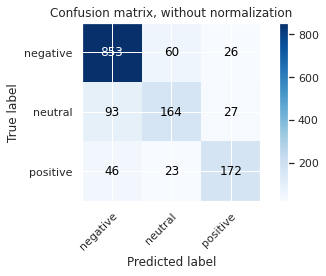

In [ ]:

# plot the confusion matrix for the test set
plot_confusion_matrix(df_test['airline_sentiment'],df_test['sentiment_pred'],
                      classes=['negative','neutral','positive'])
plt.show()

# Results

## Summary

This notebook implemented a complete character-level language model using recurrent neural networks.

### Implemented Components

- Character tokenization
- Vocabulary construction
- Character embeddings
- Recurrent Neural Networks
- Teacher forcing
- Sequence generation
- Probabilistic sampling

### Key Outcomes

- Successfully trained a recurrent neural network for character-level language modeling.
- Learned sequential dependencies between characters.
- Generated realistic text by sampling from the learned probability distribution.
- Demonstrated autoregressive sequence generation using recurrent hidden states.

# Conclusion

This notebook demonstrated how recurrent neural networks can be adapted from sequence prediction to sequence generation. By learning the probability distribution over characters, the model generates coherent text one character at a time using autoregressive decoding. These concepts provide the foundation for more advanced generative language models and modern sequence generation techniques.